In [12]:
import torch as tc
import numpy as np
import matplotlib.pyplot as plt
import mixfunn as my
from tqdm import tqdm
import math
from qutip import destroy, hinton, basis, mesolve, qeye

device = "cuda" 
#device =tc.device("cuda" if tc.cuda.is_available() else "cpu")
print(f"Dispositivo em uso: {device}")

Dispositivo em uso: cuda


In [13]:
def simulate_transmon(t_points):
    # Parâmetros do Transmon (em unidades de GHz, por exemplo)
    N = 5  # Número de níveis
    f_q = 5.0  # Frequência do qubit (0 -> 1) em GHz
    alpha = -0.3  # Anarmonicidade em GHz (típico para transmons)

    # Operadores
    a = destroy(N)
    adag = a.dag()

    # Hamiltoniano do Transmon (Duffing Oscillator)
    # H = f_q * a.dag() * a + (alpha/2) * a.dag() * a.dag() * a * a
    H0 = f_q * adag * a + (alpha / 2.0)*(a.dag() +a)*(a.dag() +a)*(a.dag() +a)*(a.dag() +a) #

    # 1. Calcular Níveis de Energia
    Omega = 1.0  # Força do drive (Rabi frequency) em GHz
    H_drive = Omega * (a + adag)

    # Hamiltoniano total
    # H = [H0, [H_drive, w0]]
    H = H0+H_drive
    args = {'wd': f_q}

    # Estado inicial: fundamental |0>
    psi0 = basis(N, 0)

    # Tempos de simulação
    tlist =t_points


    # Resolver a equação de mestre (sem dissipação por enquanto)
    result = mesolve(H, psi0, tlist, [], [basis(N, i) * basis(N, i).dag() for i in range(N)], args=args)
    expect = tc.tensor( np.array( result.expect)).transpose(0, 1)
    return expect

In [14]:
tfinal = 2.2
N      = 300
Nedo   = 10
Nfield = 0

time =  np.linspace(0,tfinal, N)
data = simulate_transmon(time)
data = tc.tensor(data).to(device)

/tmp/ipykernel_3741507/457816580.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = tc.tensor(data).to(device)


In [15]:
X_vector = my.MixFunn(
        N_layers = 2,
        N_neuro = 5,
        N_output = Nedo,
        second_order_function = True).to(device)

opt = tc.optim.Adam(
        X_vector.parameters(), lr=0.01, betas=(0.9,0.9))

time = tc.linspace(
        0,
        tfinal,
        N,
        dtype = tc.float32,
        device = device,
        requires_grad = True).reshape((-1, 1))

In [16]:
def compute_term1_batched(y, time):
    n_out = y.shape[1]
    grad_outputs = tc.eye(n_out, device=y.device, dtype=y.dtype)          # [n_out, n_out]
    grad_outputs = grad_outputs[:, None, :].expand(-1, y.shape[0], -1)    # [n_out, N, n_out]
    grads = tc.autograd.grad(
        outputs=y,
        inputs=time,
        grad_outputs=grad_outputs,
        create_graph=True,
        is_grads_batched=True
    )[0]  # grads: [n_out, N, 1]
    return grads.squeeze(-1).transpose(0, 1)  # term1: [N, n_out]

100%|██████████| 10000/10000 [04:52<00:00, 34.21it/s]


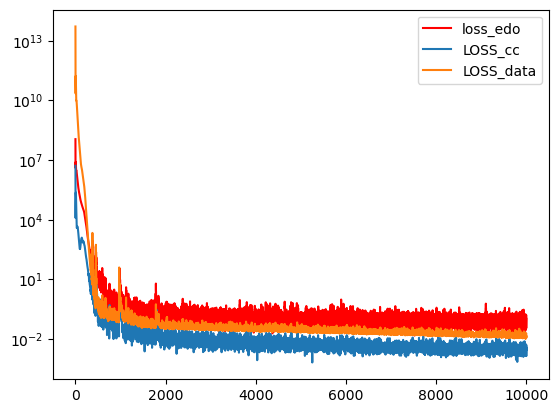

In [17]:
epocas  = 10000
factor_time = 1
# Frequência do Qubit (f_q) usada no QuTiP
f_q = 5.0 * factor_time 

# As energias diagonais devem ser puramente os níveis do oscilador harmônico (n * f_q)
E0 = 0.0 * f_q
E1 = 1.0 * f_q
E2 = 2.0 * f_q
E3 = 3.0 * f_q
E4 = 4.0 * f_q

# O resto continua igual
alfa = -0.3 * factor_time

wt = tc.ones((len(time), 1), device=device)

LOSS = []
LOSS1 = []
LOSS2 = []
LOSS3 = []
hisorty_of_param = []
for _ in tqdm(range(epocas)):
    ####### Forward pass #######
    y = X_vector(time)

    ######## Los edo #######
    # term1 = []
    # for i in range(y.shape[1]):
    #     term1.append(tc.autograd.grad(outputs=y[:, i],
    #                                 inputs=time,
    #                                 grad_outputs=tc.ones_like(y[:, i]),
    #                                 #retain_graph = True,
    #                                 create_graph=True)[0])
    # term1 = tc.cat(term1, dim=1)
    term1 = compute_term1_batched(y, time)
    
    I0 = y[:, 0:1]
    I1 = y[:, 1:2]
    I2 = y[:, 2:3]
    I3 = y[:, 3:4]
    I4 = y[:, 4:5]
    R0 = y[:, 5:6]
    R1 = y[:, 6:7]
    R2 = y[:, 7:8]
    R3 = y[:, 8:9]
    R4 = y[:, 9:10]

    # # Parte Real
    LOSS_edo = (term1[:, 0:1] + (E0 * R0 + 1.5 * alfa * R0 + 3 * math.sqrt(2) * alfa * R2 + math.sqrt(6) * alfa * R4 + wt * R1))**2
    LOSS_edo += (term1[:, 1:2] + (E1 * R1 + 7.5 * alfa * R1 + 5 * math.sqrt(6) * alfa * R3 + wt * (R0 + math.sqrt(2) * R2)))**2
    LOSS_edo += (term1[:, 2:3] + (E2 * R2 + 3 * math.sqrt(2) * alfa * R0 + 19.5 * alfa * R2 + 9 * math.sqrt(3) * alfa * R4 + wt * (math.sqrt(2) * R1 + math.sqrt(3) * R3)))**2
    LOSS_edo += (term1[:, 3:4] + (E3 * R3 + 5 * math.sqrt(6) * alfa * R1 + 27.5 * alfa * R3 + wt * (math.sqrt(3) * R2 + math.sqrt(4) * R4)))**2
    LOSS_edo += (term1[:, 4:5] + (E4 * R4 + math.sqrt(6) * alfa * R0 + 9 * math.sqrt(3) * alfa * R2 + 14 * alfa * R4 + wt * (math.sqrt(4) * R3)))**2

    # Parte Imaginaria
    LOSS_edo += (term1[:, 5:6] - (E0 * I0 + 1.5 * alfa * I0 + 3 * math.sqrt(2) * alfa * I2 + math.sqrt(6) * alfa * I4 + wt * I1))**2
    LOSS_edo += (term1[:, 6:7] - (E1 * I1 + 7.5 * alfa * I1 + 5 * math.sqrt(6) * alfa * I3 + wt * (I0 + math.sqrt(2) * I2)))**2
    LOSS_edo += (term1[:, 7:8] - (E2 * I2 + 3 * math.sqrt(2) * alfa * I0 + 19.5 * alfa * I2 + 9 * math.sqrt(3) * alfa * I4 + wt * (math.sqrt(2) * I1 + math.sqrt(3) * I3)))**2
    LOSS_edo += (term1[:, 8:9] - (E3 * I3 + 5 * math.sqrt(6) * alfa * I1 + 27.5 * alfa * I3 + wt * (math.sqrt(3) * I2 + math.sqrt(4) * I4)))**2
    LOSS_edo += (term1[:, 9:10] - (E4 * I4 + math.sqrt(6) * alfa * I0 + 9 * math.sqrt(3) * alfa * I2 + 14 * alfa * I4 + wt * (math.sqrt(4) * I3)))**2

    LOSS_edo = LOSS_edo.mean()

    ####### loss data(target conditions) #######
    LOSS_cc = ((R0[0] - 1)**2)
    LOSS_cc += ((R1[0] - 0)**2)
    LOSS_cc += ((R2[0] + 0)**2)
    LOSS_cc += ((R3[0] + 0)**2)
    LOSS_cc += ((R4[0] + 0)**2)
    LOSS_cc += ((I0[0] + 0)**2)
    LOSS_cc += ((I1[0] + 0)**2)
    LOSS_cc += ((I2[0] + 0)**2)
    LOSS_cc += ((I3[0] + 0)**2)
    LOSS_cc += ((I4[0] + 0)**2)
    LOSS_cc = LOSS_cc.mean()

    ####### loss data #######
    expect1 =  (I0)**2+(R0)**2
    expect2 =  (I1)**2+(R1)**2
    expect3 =  (I2)**2+(R2)**2
    expect4 =  (I3)**2+(R3)**2
    expect5 =  (I4)**2+(R4)**2
    
    LOSS_data  = (expect1 - data[:,0:1] )**2
    LOSS_data += (expect2 - data[:,1:2] )**2
    LOSS_data += 10*(expect3 - data[:,2:3] )**2
    LOSS_data += 30*(expect4 - data[:,3:4] )**2
    LOSS_data += 50*(expect5 - data[:,4:5] )**2
    LOSS_data = LOSS_data.mean()
    loss_i = LOSS_edo + LOSS_cc + LOSS_data
    #loss_i = LOSS_data

    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()

    LOSS1.append(LOSS_edo.detach().cpu().numpy())
    LOSS2.append(LOSS_cc.detach().cpu().numpy())
    LOSS.append(loss_i.detach().cpu().numpy())
    LOSS3.append(LOSS_data.cpu().detach().numpy())


#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1, 'r-', label="loss_edo")
plt.plot(LOSS2, label="LOSS_cc")
plt.plot(LOSS3, label="LOSS_data")

plt.yscale("log")
plt.legend()
plt.show()

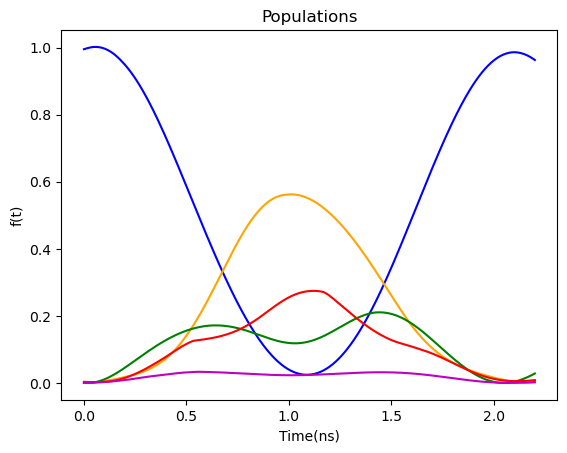

In [18]:
t_points = np.linspace(0, tfinal, N)
with tc.no_grad():
    X_ = X_vector(time).detach().cpu().numpy()
# w_opt=(1-np.exp(-t_points))*(X_[:,1])
# w_opt=np.sin(np.pi/2*t_points)**2*(X_[:,6])

plt.plot(t_points, (X_[:, 0])**2 + (X_[:, 5])**2, "b")
plt.plot(t_points, (X_[:, 1])**2 + (X_[:, 6])**2, "orange")
plt.plot(t_points, (X_[:, 2])**2 + (X_[:, 7])**2, "g")
plt.plot(t_points, (X_[:, 3])**2 + (X_[:, 8])**2, "r")
plt.plot(t_points, (X_[:, 4])**2 + (X_[:, 9])**2, "m")
plt.xlabel('Time(ns)')
plt.ylabel('f(t)')
plt.title('Populations')
plt.show()

/tmp/ipykernel_3741507/3969306780.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = tc.tensor(data).to(device)


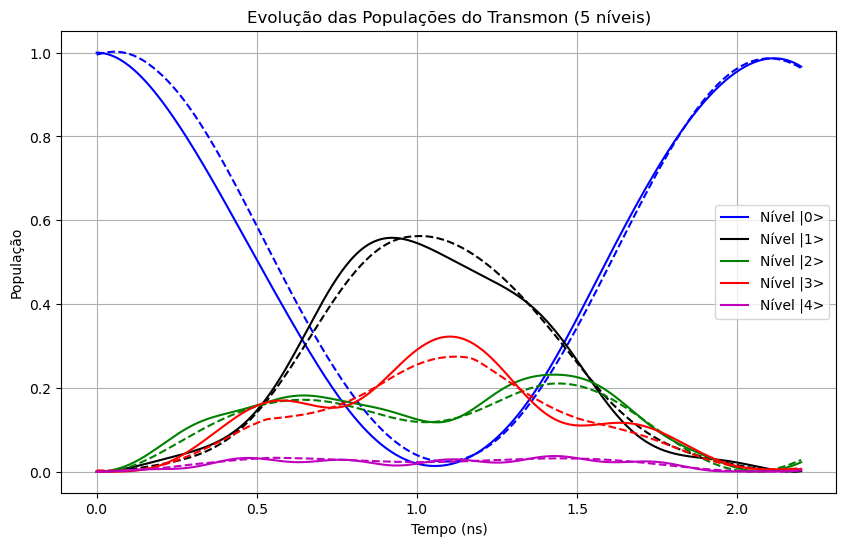

In [19]:
time =  np.linspace(0,tfinal, N)
data = simulate_transmon(time)
data = tc.tensor(data).to(device)

plt.figure(figsize=(10, 6))
plt.plot( time, 
         data[:,0:1].cpu(),"b", label=f'Nível |{0}>')
plt.plot( time,
            (X_[:,0])**2 + (X_[:,5])**2,"b--")

plt.plot(time, 
         data[:,1:2].cpu(),"k", label=f'Nível |{1}>')
plt.plot(time,
            (X_[:,1])**2 + (X_[:,6])**2,
            "k--")

plt.plot(time,
         data[:,2:3].cpu(),"g", label=f'Nível |{2}>')
plt.plot(time,
            (X_[:,2])**2 + (X_[:,7])**2,
            "g--")

plt.plot(time, 
         data[:,3:4].cpu(),"r", label=f'Nível |{3}>')
plt.plot(time,
            (X_[:,3])**2 + (X_[:,8])**2,"r--")

plt.plot(time, 
         data[:,4:5].cpu(),"m", label=f'Nível |{4}>')
plt.plot(time,
            (X_[:,4])**2 + (X_[:,9])**2,"m--")

plt.title('Evolução das Populações do Transmon (5 níveis)')
plt.xlabel('Tempo (ns)')
plt.ylabel('População')
plt.legend()
plt.grid(True)
plt.show()

### prunning 

In [20]:
import torch.nn.utils.prune as prune
prune.l1_unstructured(X_vector.layers1.project1.linear, 'weight', amount=0.1)
prune.l1_unstructured(X_vector.layers1.project1.linear, 'bias', amount=0.1)

prune.l1_unstructured(X_vector.layers2.project1.linear, 'weight', amount=0.1)
prune.l1_unstructured(X_vector.layers2.project1.linear, 'bias', amount=0.1)

p = X_vector.layers1.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
X_vector.layers1.p.data = tc.where(p < 0.01, 0.0, X_vector.layers1.p.data)

p = X_vector.layers1.p.data
L = tc.sum(abs(p))
p = abs(p)/L

values, indices = tc.sort(p)
mask = tc.zeros(indices.shape[1], device=device)
for k in range(indices.shape[1]):
    if k > int(0.2*indices.shape[1]):
        mask[indices[0][k]] = 1.0
X_vector.layers1.p.data = mask*X_vector.layers1.p.data
print(X_vector.layers1.p.data)

p = X_vector.layers2.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
X_vector.layers2.p.data = tc.where(p < 0.01, 0.0, X_vector.layers2.p.data)

p = X_vector.layers2.p.data
L = tc.sum(abs(p))
p = abs(p)/L

values, indices = tc.sort(p)
mask2 = tc.zeros(indices.shape[1], device=device)
for k in range(indices.shape[1]):
    if k > int(0.2*indices.shape[1]):
        mask2[indices[0][k]] = 1.0
X_vector.layers2.p.data = mask2*X_vector.layers2.p.data
print(X_vector.layers2.p.data)


tensor([[ 1.4267,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         -1.9811,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.3234,  0.0000,
          0.0000,  0.0000, -1.3183,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  1.4867],
        [ 0.0000,  0.0000,  0.0000, -0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  2.0925, -1.4119,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  2.4875,  0.0000,  1.8828,  0.0000,  0.0000, -1.7157,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.7703,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000, -0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000, -1.4529,  0.0000,  0.0000,  0.0000,  0.0000,  1.6950,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -2.2023,
         -1.3953,  0.0000,  0.0000,

100%|██████████| 2000/2000 [04:05<00:00,  8.16it/s]


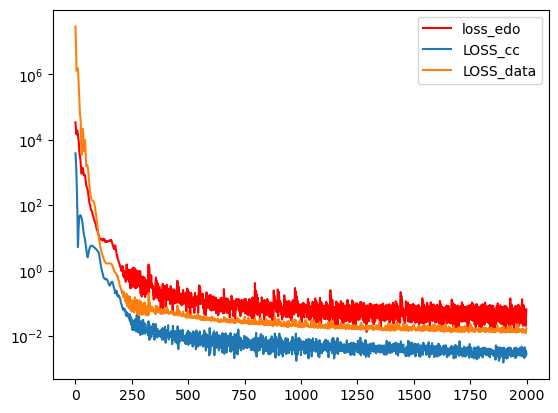

In [21]:
epocas = 2000
wt = tc.ones((len(time), 1), device=device)

time = tc.linspace(
        0,
        tfinal,
        N,
        dtype = tc.float32,
        device = device,
        requires_grad = True).reshape((-1, 1))

LOSS = []
LOSS1 = []
LOSS2 = []
LOSS3 = []
hisorty_of_param = []
for _ in tqdm(range(epocas)):
    # aplicaçao da mascara para os pesos novos
    X_vector.layers1.p.data = mask*X_vector.layers1.p.data
    X_vector.layers2.p.data = mask2*X_vector.layers2.p.data
    ####### Forward pass #######
    y = X_vector(time)

    ######## Los edo #######
    term1 = []
    for i in range(y.shape[1]):
        term1.append(tc.autograd.grad(outputs=y[:, i],
                                    inputs=time,
                                    grad_outputs=tc.ones_like(y[:, i]),
                                    #retain_graph = True,
                                    create_graph=True)[0])
    term1 = tc.cat(term1, dim=1)

    I0 = y[:, 0:1]
    I1 = y[:, 1:2]
    I2 = y[:, 2:3]
    I3 = y[:, 3:4]
    I4 = y[:, 4:5]
    R0 = y[:, 5:6]
    R1 = y[:, 6:7]
    R2 = y[:, 7:8]
    R3 = y[:, 8:9]
    R4 = y[:, 9:10]

    # Parte Real
    LOSS_edo = (term1[:, 0:1] + (E0 * R0 + 1.5 * alfa * R0 + 3 * math.sqrt(2) * alfa * R2 + math.sqrt(6) * alfa * R4 + wt * R1))**2
    LOSS_edo += (term1[:, 1:2] + (E1 * R1 + 7.5 * alfa * R1 + 5 * math.sqrt(6) * alfa * R3 + wt * (R0 + math.sqrt(2) * R2)))**2
    LOSS_edo += (term1[:, 2:3] + (E2 * R2 + 3 * math.sqrt(2) * alfa * R0 + 19.5 * alfa * R2 + 9 * math.sqrt(3) * alfa * R4 + wt * (math.sqrt(2) * R1 + math.sqrt(3) * R3)))**2
    LOSS_edo += (term1[:, 3:4] + (E3 * R3 + 5 * math.sqrt(6) * alfa * R1 + 27.5 * alfa * R3 + wt * (math.sqrt(3) * R2 + math.sqrt(4) * R4)))**2
    LOSS_edo += (term1[:, 4:5] + (E4 * R4 + math.sqrt(6) * alfa * R0 + 9 * math.sqrt(3) * alfa * R2 + 14 * alfa * R4 + wt * (math.sqrt(4) * R3)))**2

    # Parte Imaginaria
    LOSS_edo += (term1[:, 5:6] - (E0 * I0 + 1.5 * alfa * I0 + 3 * math.sqrt(2) * alfa * I2 + math.sqrt(6) * alfa * I4 + wt * I1))**2
    LOSS_edo += (term1[:, 6:7] - (E1 * I1 + 7.5 * alfa * I1 + 5 * math.sqrt(6) * alfa * I3 + wt * (I0 + math.sqrt(2) * I2)))**2
    LOSS_edo += (term1[:, 7:8] - (E2 * I2 + 3 * math.sqrt(2) * alfa * I0 + 19.5 * alfa * I2 + 9 * math.sqrt(3) * alfa * I4 + wt * (math.sqrt(2) * I1 + math.sqrt(3) * I3)))**2
    LOSS_edo += (term1[:, 8:9] - (E3 * I3 + 5 * math.sqrt(6) * alfa * I1 + 27.5 * alfa * I3 + wt * (math.sqrt(3) * I2 + math.sqrt(4) * I4)))**2
    LOSS_edo += (term1[:, 9:10] - (E4 * I4 + math.sqrt(6) * alfa * I0 + 9 * math.sqrt(3) * alfa * I2 + 14 * alfa * I4 + wt * (math.sqrt(4) * I3)))**2

    LOSS_edo = LOSS_edo.mean()

    ####### loss data(target conditions) #######
    LOSS_cc = ((R0[0] - 1)**2)
    LOSS_cc += ((R1[0] - 0)**2)
    LOSS_cc += ((R2[0] + 0)**2)
    LOSS_cc += ((R3[0] + 0)**2)
    LOSS_cc += ((R4[0] + 0)**2)
    LOSS_cc += ((I0[0] + 0)**2)
    LOSS_cc += ((I1[0] + 0)**2)
    LOSS_cc += ((I2[0] + 0)**2)
    LOSS_cc += ((I3[0] + 0)**2)
    LOSS_cc += ((I4[0] + 0)**2)
    LOSS_cc = LOSS_cc.mean()

    ####### loss data #######
    expect1 =  (I0)**2+(R0)**2
    expect2 =  (I1)**2+(R1)**2
    expect3 =  (I2)**2+(R2)**2
    expect4 =  (I3)**2+(R3)**2
    expect5 =  (I4)**2+(R4)**2
    
    LOSS_data  = (expect1 - data[:,0:1] )**2
    LOSS_data += (expect2 - data[:,1:2] )**2
    LOSS_data += 10*(expect3 - data[:,2:3] )**2
    LOSS_data += 30*(expect4 - data[:,3:4] )**2
    LOSS_data += 50*(expect5 - data[:,4:5] )**2
    LOSS_data = LOSS_data.mean()
    loss_i = LOSS_edo + LOSS_cc + LOSS_data

    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()

    LOSS1.append(LOSS_edo.detach().cpu().numpy())
    LOSS2.append(LOSS_cc.detach().cpu().numpy())
    LOSS.append(loss_i.detach().cpu().numpy())
    LOSS3.append(LOSS_data.cpu().detach().numpy())


#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1, 'r-', label="loss_edo")
plt.plot(LOSS2, label="LOSS_cc")
plt.plot(LOSS3, label="LOSS_data")

plt.yscale("log")
plt.legend()
plt.show()

/tmp/ipykernel_3741507/3969306780.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = tc.tensor(data).to(device)


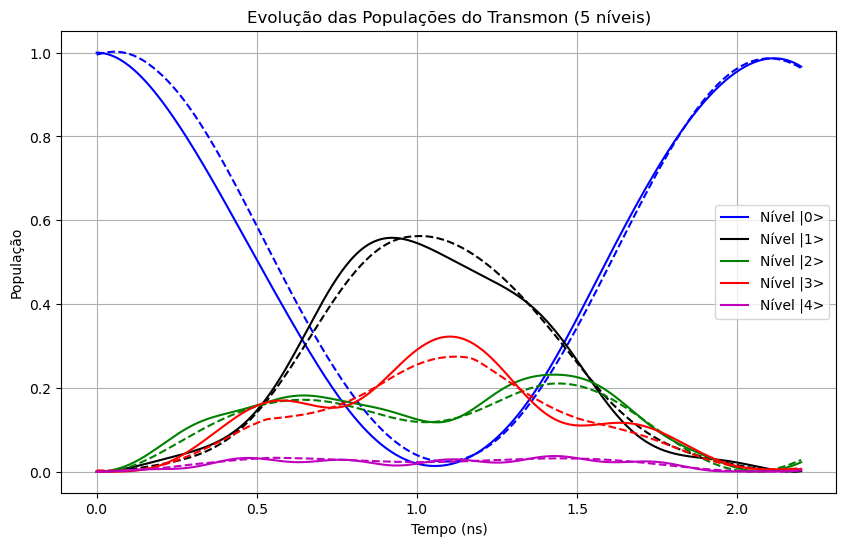

In [22]:
time =  np.linspace(0,tfinal, N)
data = simulate_transmon(time)
data = tc.tensor(data).to(device)

plt.figure(figsize=(10, 6))
plt.plot( time, 
         data[:,0:1].cpu(),"b", label=f'Nível |{0}>')
plt.plot( time,
            (X_[:,0])**2 + (X_[:,5])**2,"b--")

plt.plot(time, 
         data[:,1:2].cpu(),"k", label=f'Nível |{1}>')
plt.plot(time,
            (X_[:,1])**2 + (X_[:,6])**2,
            "k--")

plt.plot(time,
         data[:,2:3].cpu(),"g", label=f'Nível |{2}>')
plt.plot(time,
            (X_[:,2])**2 + (X_[:,7])**2,
            "g--")

plt.plot(time, 
         data[:,3:4].cpu(),"r", label=f'Nível |{3}>')
plt.plot(time,
            (X_[:,3])**2 + (X_[:,8])**2,"r--")

plt.plot(time, 
         data[:,4:5].cpu(),"m", label=f'Nível |{4}>')
plt.plot(time,
            (X_[:,4])**2 + (X_[:,9])**2,"m--")

plt.title('Evolução das Populações do Transmon (5 níveis)')
plt.xlabel('Tempo (ns)')
plt.ylabel('População')
plt.legend()
plt.grid(True)
plt.show()